<a href="https://colab.research.google.com/github/VrishankDesai/Ai-in-healthcare/blob/main/DNA_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [6]:
# ─────────────────────────────────────────
# 1. UPLOAD AND PARSE FILE
# ─────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # upload promoters_data.txt

# Correct the filename to match the uploaded file
lines = uploaded['promoters.data (4).txt'].decode('utf-8').strip().split('\n')

labels    = []
sequences = []

for line in lines:
    parts = line.strip().split(',')
    label = parts[0].strip()           # '+' or '-'
    seq   = parts[-1].strip()          # DNA string (57 chars)
    labels.append(label)
    sequences.append(seq)

print(f"Total samples: {len(sequences)}")
print(f"Sample sequence: {sequences[0]}")
print(f"Sequence length: {len(sequences[0])}")
print(f"Label counts: {pd.Series(labels).value_counts().to_dict()}")

Saving promoters.data.txt to promoters.data (4).txt
Total samples: 106
Sample sequence: tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgcgggcttgtcgt
Sequence length: 57
Label counts: {'+': 53, '-': 53}


In [7]:
# ─────────────────────────────────────────
# 2. ENCODE DNA SEQUENCES
# ─────────────────────────────────────────
# Each base (a, t, g, c) is mapped to a number
base_map = {'a': 0, 't': 1, 'g': 2, 'c': 3}

X = []
for seq in sequences:
    encoded = [base_map.get(b, -1) for b in seq.lower()]
    X.append(encoded)

X = np.array(X)

# Encode labels: '+' -> 1, '-' -> 0
le = LabelEncoder()
y  = le.fit_transform(labels)   # '+' = 1, '-' = 0

print(f"\nFeature matrix shape: {X.shape}")
print(f"Classes: {le.classes_}")


Feature matrix shape: (106, 57)
Classes: ['+' '-']


In [8]:
# ─────────────────────────────────────────
# 3. TRAIN TEST SPLIT
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 84, Test: 22


In [9]:
# ─────────────────────────────────────────
# 4. DEFINE ALL MODELS
# ─────────────────────────────────────────
models = {
    "Decision Tree"   : DecisionTreeClassifier(random_state=42),
    "SVM (RBF)"       : SVC(kernel='rbf', random_state=42),           # Radial Basis Function kernel
    "Random Forest"   : RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN"             : KNeighborsClassifier(n_neighbors=5),
    "AdaBoost"        : AdaBoostClassifier(n_estimators=50, random_state=42),
    "MLP Classifier"  : MLPClassifier(hidden_layer_sizes=(64, 32),
                                      max_iter=500, random_state=42)
}

In [10]:
# ─────────────────────────────────────────
# 5. TRAIN AND EVALUATE ALL MODELS
# ─────────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred,
                                target_names=['Non-Promoter', 'Promoter']))


── Decision Tree ──
              precision    recall  f1-score   support

Non-Promoter       0.64      0.64      0.64        11
    Promoter       0.64      0.64      0.64        11

    accuracy                           0.64        22
   macro avg       0.64      0.64      0.64        22
weighted avg       0.64      0.64      0.64        22


── SVM (RBF) ──
              precision    recall  f1-score   support

Non-Promoter       0.89      0.73      0.80        11
    Promoter       0.77      0.91      0.83        11

    accuracy                           0.82        22
   macro avg       0.83      0.82      0.82        22
weighted avg       0.83      0.82      0.82        22


── Random Forest ──
              precision    recall  f1-score   support

Non-Promoter       0.90      0.82      0.86        11
    Promoter       0.83      0.91      0.87        11

    accuracy                           0.86        22
   macro avg       0.87      0.86      0.86        22
weighted avg   

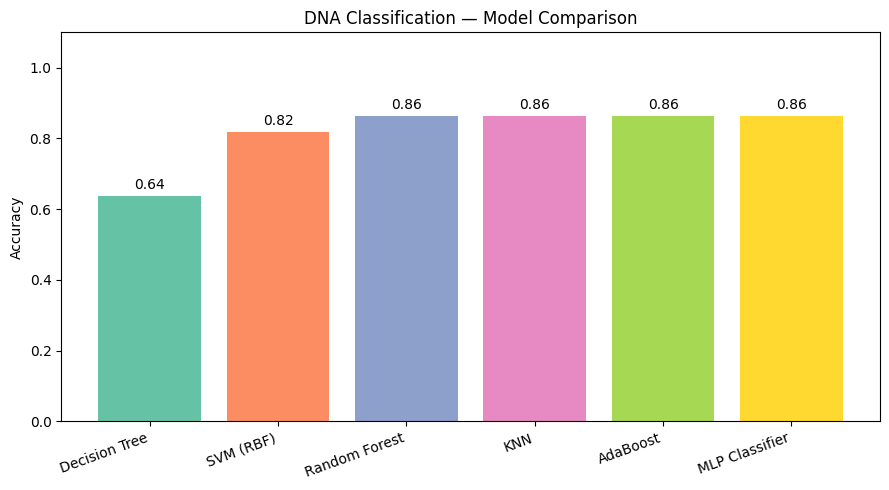

In [11]:
# ─────────────────────────────────────────
# 6. MODEL COMPARISON BAR CHART
# ─────────────────────────────────────────
plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), results.values(),
               color=sns.color_palette("Set2", len(results)))
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("DNA Classification — Model Comparison")
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

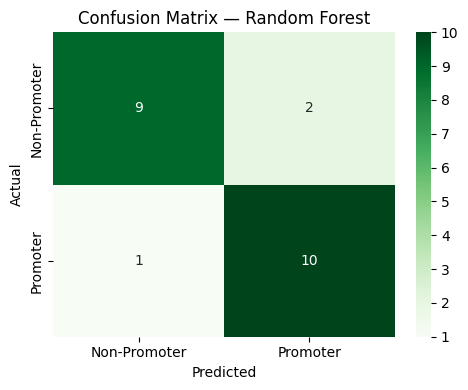


Best Model: Random Forest with accuracy 0.86


In [12]:
# ─────────────────────────────────────────
# 7. CONFUSION MATRIX FOR BEST MODEL
# ─────────────────────────────────────────
best_name  = max(results, key=results.get)
best_model = models[best_name]
y_best     = best_model.predict(X_test)
cm         = confusion_matrix(y_test, y_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Promoter', 'Promoter'],
            yticklabels=['Non-Promoter', 'Promoter'])
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nBest Model: {best_name} with accuracy {results[best_name]:.2f}")